In [14]:
from transformers import BertTokenizer, AutoModelForSequenceClassification

# 使用现成的 FinBERT 模型
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=5,   # 你定义的五类标签
    ignore_mismatched_sizes=True # 关键参数
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
# 定义 tokenize 函数
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# 假设你已经有 train.csv 和 val.csv
from datasets import load_dataset
dataset = load_dataset("csv", data_files={"train": "train.csv", "validation": "val.csv"})

# 应用分词
tokenized_dataset = dataset.map(tokenize, batched=True)

# 设置 PyTorch 格式
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/24224 [00:00<?, ? examples/s]

Map:   0%|          | 0/6056 [00:00<?, ? examples/s]

In [16]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./finbert_finetuned",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",          # 注意这里用 eval_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,                 # 每隔多少步保存一次
    eval_steps=500                  # 每隔多少步做一次验证
)


In [17]:
from transformers import Trainer

trainer = Trainer(
    model=model,  # 你之前加载的 AutoModelForSequenceClassification(num_labels=5, ignore_mismatched_sizes=True)
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)


In [18]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,1.559900,1.565833
2,1.529700,1.521891
3,1.437900,1.520877


TrainOutput(global_step=4542, training_loss=1.5281611450544699, metrics={'train_runtime': 1145.8918, 'train_samples_per_second': 63.42, 'train_steps_per_second': 3.964, 'total_flos': 1.912132164914381e+16, 'train_loss': 1.5281611450544699, 'epoch': 3.0})

In [19]:
trainer.save_model("./finbert_finetuned")
tokenizer.save_pretrained("./finbert_finetuned")


('./finbert_finetuned\\tokenizer_config.json',
 './finbert_finetuned\\special_tokens_map.json',
 './finbert_finetuned\\vocab.txt',
 './finbert_finetuned\\added_tokens.json')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/6940 [00:00<?, ? examples/s]

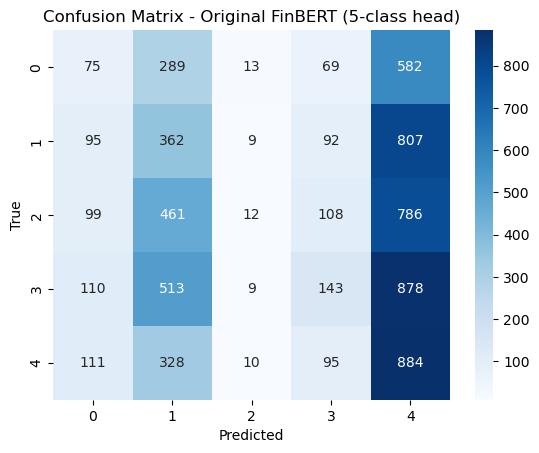

分类报告 - 原始 FinBERT (5 类头)
              precision    recall  f1-score   support

           0       0.15      0.07      0.10      1028
           1       0.19      0.27      0.22      1365
           2       0.23      0.01      0.02      1466
           3       0.28      0.09      0.13      1653
           4       0.22      0.62      0.33      1428

    accuracy                           0.21      6940
   macro avg       0.21      0.21      0.16      6940
weighted avg       0.22      0.21      0.16      6940



In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 指定模型目录（原始 FinBERT）
model_dir = "ProsusAI/finbert"

# 2. 加载分词器和模型，替换分类头为 5 类
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=5,                  # 替换为 5 类
    ignore_mismatched_sizes=True   # 允许替换分类层
)

# 3. 加载新的验证集 CSV
dataset = load_dataset("csv", data_files={"validation": "test_timeseries.csv"})
val_dataset = dataset["validation"]

# 4. 分词
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. 定义 Trainer（只做预测，不训练）
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. 在验证集上跑预测
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. 可视化混淆矩阵
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Original FinBERT (5-class head)")
plt.show()

# 8. 分类报告
print("分类报告 - 原始 FinBERT (5 类头)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))


Map:   0%|          | 0/6940 [00:00<?, ? examples/s]

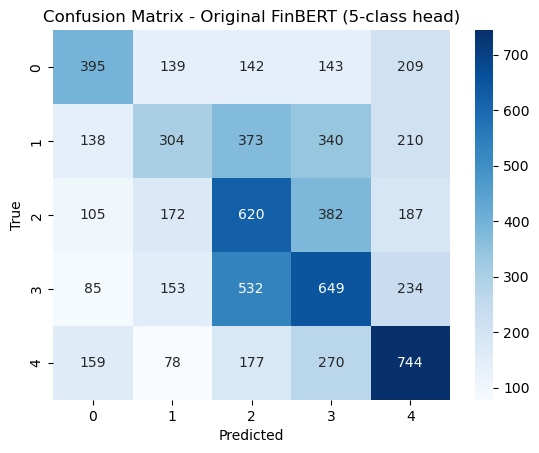

分类报告 - 原始 FinBERT (5 类头)
              precision    recall  f1-score   support

           0       0.45      0.38      0.41      1028
           1       0.36      0.22      0.27      1365
           2       0.34      0.42      0.37      1466
           3       0.36      0.39      0.38      1653
           4       0.47      0.52      0.49      1428

    accuracy                           0.39      6940
   macro avg       0.40      0.39      0.39      6940
weighted avg       0.39      0.39      0.39      6940



In [ ]:
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 指定模型目录（原始 FinBERT）
model_dir = "./finbert_finetuned"

# 2. 加载分词器和模型，替换分类头为 5 类
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir,
    num_labels=5,                  # 替换为 5 类
    ignore_mismatched_sizes=True   # 允许替换分类层
)

# 3. 加载新的验证集 CSV
dataset = load_dataset("csv", data_files={"validation": "test_timeseries.csv"})
val_dataset = dataset["validation"]

# 4. 分词
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 5. 定义 Trainer（只做预测，不训练）
training_args = TrainingArguments(
    output_dir="./tmp_eval",
    do_train=False,
    do_eval=True,
    per_device_eval_batch_size=16,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_val,
)

# 6. 在验证集上跑预测
predictions = trainer.predict(tokenized_val)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 7. 可视化混淆矩阵
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fintuned FinBERT (5-class head)")
plt.show()

# 8. 分类报告
print("分类报告 - 微调后的 FinBERT (5 类头)")
print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))


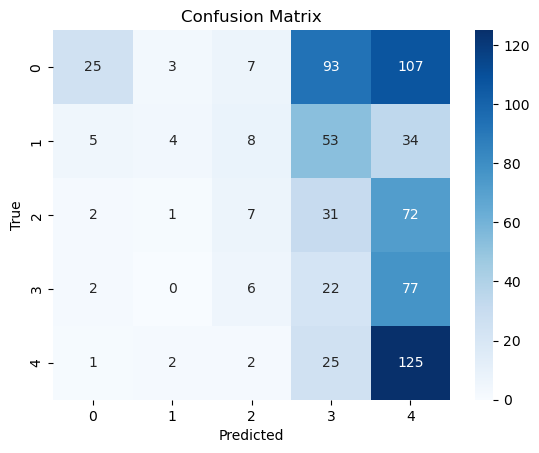

              precision    recall  f1-score   support

           0       0.71      0.11      0.19       235
           1       0.40      0.04      0.07       104
           2       0.23      0.06      0.10       113
           3       0.10      0.21      0.13       107
           4       0.30      0.81      0.44       155

    accuracy                           0.26       714
   macro avg       0.35      0.24      0.18       714
weighted avg       0.41      0.26      0.20       714



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 显式指定所有类别
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))


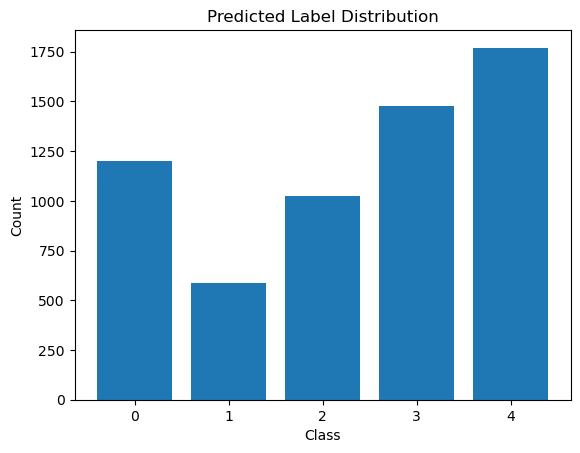

In [22]:
import numpy as np

unique, counts = np.unique(pred_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Label Distribution")
plt.show()


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/23339 [00:00<?, ? examples/s]

Map:   0%|          | 0/6940 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,1.540700,1.617930
2,1.469100,1.776118
3,1.446100,1.776228


最终模型已保存到 ./finbert_timeseries


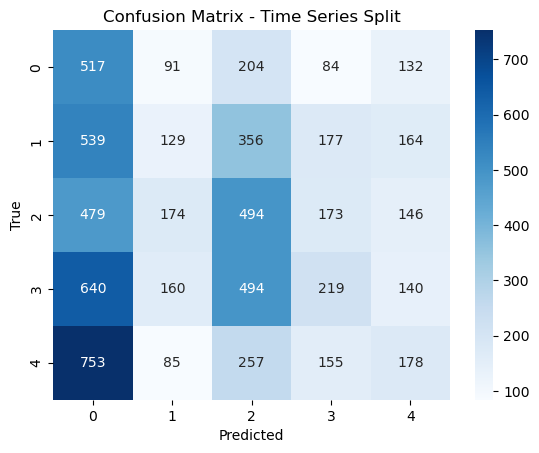

分类报告 - 时间序列模型
              precision    recall  f1-score   support

           0       0.18      0.50      0.26      1028
           1       0.20      0.09      0.13      1365
           2       0.27      0.34      0.30      1466
           3       0.27      0.13      0.18      1653
           4       0.23      0.12      0.16      1428

    accuracy                           0.22      6940
   macro avg       0.23      0.24      0.21      6940
weighted avg       0.24      0.22      0.20      6940



In [33]:
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 使用 FinBERT 模型
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# 加载时间序列划分的数据
dataset = load_dataset("csv", data_files={
    "train": "train_timeseries.csv",
    "validation": "test_timeseries.csv"
})

# 分词
tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 定义训练参数
training_args = TrainingArguments(
    output_dir="./finbert_timeseries",
    overwrite_output_dir=True,
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",   # 注意你版本里是 eval_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,
    eval_steps=500
)

# 初始化模型
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=5,
    ignore_mismatched_sizes=True
)

# 定义 Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

# 训练
trainer.train()

# 保存最终模型
trainer.save_model("./finbert_timeseries")
tokenizer.save_pretrained("./finbert_timeseries")
print("最终模型已保存到 ./finbert_timeseries")

# 验证集预测
predictions = trainer.predict(tokenized_dataset["validation"])
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# 混淆矩阵
cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Time Series Split")
plt.show()

# 分类报告
print("分类报告 - 时间序列模型")
print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))


In [ ]:
# from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# from datasets import load_dataset
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix, classification_report

# # 1. 加载原始 FinBERT tokenizer
# tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

# def tokenize(batch):
#     return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# # 2. 加载时间序列划分的数据
# dataset = load_dataset("csv", data_files={
#     "train": "train_timeseries.csv",
#     "validation": "test_timeseries.csv"
# })

# # 3. 分词
# tokenized_dataset = dataset.map(tokenize, batched=True)
# tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# # 4. 初始化模型：替换分类头为 5 类
# model = AutoModelForSequenceClassification.from_pretrained(
#     "ProsusAI/finbert",
#     num_labels=5,
#     ignore_mismatched_sizes=True   # 允许替换分类层
# )

# # 5. 定义训练参数（这里只跑验证，不训练）
# training_args = TrainingArguments(
#     output_dir="./finbert_original_5class",
#     do_train=False,
#     do_eval=True,
#     per_device_eval_batch_size=16,
#     logging_dir="./logs",
# )

# # 6. 定义 Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     eval_dataset=tokenized_dataset["validation"],
# )

# # 7. 在验证集上跑预测
# predictions = trainer.predict(tokenized_dataset["validation"])
# pred_labels = predictions.predictions.argmax(-1)
# true_labels = predictions.label_ids

# # 8. 可视化混淆矩阵
# cm = confusion_matrix(true_labels, pred_labels, labels=[0,1,2,3,4])
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix - Original FinBERT (5-class head)")
# plt.show()

# # 9. 分类报告
# print("分类报告 - 原始 FinBERT (5 类头)")
# print(classification_report(true_labels, pred_labels, labels=[0,1,2,3,4]))


Map:   0%|          | 0/23340 [00:00<?, ? examples/s]

KeyboardInterrupt: 